In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)


dataset used: https://www.kaggle.com/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset/data?select=departments.csv

In [5]:
response = s3.list_objects_v2(Bucket=bucket, Prefix="raw/")
for obj in response.get("Contents", []):
    print(obj["Key"])

raw/
raw/aisles.csv
raw/departments.csv
raw/order_products__prior.csv
raw/order_products__train.csv
raw/orders.csv
raw/products.csv


In [6]:
import boto3
import pandas as pd
from io import StringIO

s3 = boto3.client("s3", region_name="us-east-1")
bucket = "food-waste-project"

def load_csv(key, **kwargs):
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(StringIO(obj["Body"].read().decode("utf-8")), **kwargs)

orders = load_csv("raw/orders.csv",
    usecols=["order_id", "user_id", "order_number", "order_dow", "order_hour_of_day", "days_since_prior_order"])

order_products = load_csv("raw/order_products__train.csv",
    usecols=["order_id", "product_id", "reordered"])

products = load_csv("raw/products.csv",
    usecols=["product_id", "product_name", "aisle_id", "department_id"])

aisles = load_csv("raw/aisles.csv")
departments = load_csv("raw/departments.csv")

print("All files loaded!")

All files loaded!


In [7]:
#merge tables
df = order_products.merge(orders, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(aisles, on="aisle_id", how="left")
df = df.merge(departments, on="department_id", how="left")

print(df.shape)
df.head()

(1384617, 13)


,order_id,product_id,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,1,49302,1,112108,4,4,10,9.0,Bulgarian Yogurt,120,16,yogurt,dairy eggs
1,1,11109,1,112108,4,4,10,9.0,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs
2,1,10246,0,112108,4,4,10,9.0,Organic Celery Hearts,83,4,fresh vegetables,produce
3,1,49683,0,112108,4,4,10,9.0,Cucumber Kirby,83,4,fresh vegetables,produce
4,1,43633,1,112108,4,4,10,9.0,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods


In [8]:
#basic cleaning
df["days_since_prior_order"] = df["days_since_prior_order"].fillna(0)


In [9]:
#feature engineering
# product popularity = how many times product appears
product_counts = df.groupby(["product_id", "product_name"]).size().reset_index(name="product_popularity")
df = df.merge(product_counts, on="product_id", how="left")

# total orders per user
user_order_counts = df.groupby("user_id")["order_number"].max().reset_index(name="user_total_orders")
df = df.merge(user_order_counts, on="user_id", how="left")

print(df.shape)
df.head()

(1384617, 16)


,order_id,product_id,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name_x,aisle_id,department_id,aisle,department,product_name_y,product_popularity,user_total_orders
0,1,49302,1,112108,4,4,10,9.0,Bulgarian Yogurt,120,16,yogurt,dairy eggs,Bulgarian Yogurt,8,4
1,1,11109,1,112108,4,4,10,9.0,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs,Organic 4% Milk Fat Whole Milk Cottage Cheese,144,4
2,1,10246,0,112108,4,4,10,9.0,Organic Celery Hearts,83,4,fresh vegetables,produce,Organic Celery Hearts,1062,4
3,1,49683,0,112108,4,4,10,9.0,Cucumber Kirby,83,4,fresh vegetables,produce,Cucumber Kirby,2413,4
4,1,43633,1,112108,4,4,10,9.0,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods,Lightly Smoked Sardines in Olive Oil,24,4


In [10]:
df.columns

Index(['order_id', 'product_id', 'reordered', 'user_id', 'order_number',
       'order_dow', 'order_hour_of_day', 'days_since_prior_order',
       'product_name_x', 'aisle_id', 'department_id', 'aisle', 'department',
       'product_name_y', 'product_popularity', 'user_total_orders'],
      dtype='object')

In [11]:
#define x and y
feature_cols = [
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order",
    "product_popularity",
    "user_total_orders",
    "aisle",
    "department"
]

X = df[feature_cols]
y = df["reordered"]

print(y.value_counts())
print(y.value_counts(normalize=True))

reordered
1    828824
0    555793
Name: count, dtype: int64
reordered
1    0.598594
0    0.401406
Name: proportion, dtype: float64


about 60% reordered, about 40% didnt

In [12]:
#sample so it doesnt crash
sample_idx = X.sample(n=100000, random_state=2026).index

X = X.loc[sample_idx]
y = y.loc[sample_idx]

print(X.shape)

(100000, 8)


In [13]:
#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=2026,
    stratify=y
)

print(X_train.shape, X_test.shape)

(80000, 8) (20000, 8)


In [14]:
#build logisitic regression
numeric_features = [
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order",
    "product_popularity",
    "user_total_orders"
]

categorical_features = [
    "aisle",
    "department"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [15]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.6647
Precision: 0.6811624072547403
Recall: 0.8276293823038398
F1: 0.7472867048537836
ROC-AUC: 0.7074558334963925


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [17]:
#random forest
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_leaf=5,
        random_state=2026,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [18]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Random Forest Results
Accuracy: 0.6654
Precision: 0.6791813499593385
Recall: 0.8365609348914859
F1: 0.7497007779772591
ROC-AUC: 0.7111515399731057

Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.41      0.50      8020
           1       0.68      0.84      0.75     11980

    accuracy                           0.67     20000
   macro avg       0.65      0.62      0.62     20000
weighted avg       0.66      0.67      0.65     20000



In [19]:
#compare logistic regression and random forest
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression    0.6647   0.681162  0.827629  0.747287  0.707456
1        Random Forest    0.6654   0.679181  0.836561  0.749701  0.711152


In [20]:
from sklearn.ensemble import GradientBoostingClassifier

In [21]:
gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=2026
    ))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

In [22]:
print("Gradient Boosting Results")
print("Accuracy:", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall:", recall_score(y_test, gb_pred))
print("F1:", f1_score(y_test, gb_pred))
print("ROC-AUC:", roc_auc_score(y_test, gb_prob))

Gradient Boosting Results
Accuracy: 0.67055
Precision: 0.6915097690941385
Recall: 0.8124373956594324
F1: 0.7471118787180964
ROC-AUC: 0.718046161724237


In [23]:
#comparison table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Gradient Boosting"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression   0.66470   0.681162  0.827629  0.747287  0.707456
1        Random Forest   0.66540   0.679181  0.836561  0.749701  0.711152
2    Gradient Boosting   0.67055   0.691510  0.812437  0.747112  0.718046


We evaluated three models: Logistic Regression, Random Forest, and Gradient Boosting. The results show that Gradient Boosting achieved the best overall performance, with an accuracy of 67.06%, precision of 69.15%, recall of 81.24%, F1-score of 74.71%, and ROC-AUC of 0.718.

Compared to Logistic Regression and Random Forest, Gradient Boosting provided improvements in both accuracy and ROC-AUC, indicating a stronger ability to distinguish between reordered and non-reordered products.

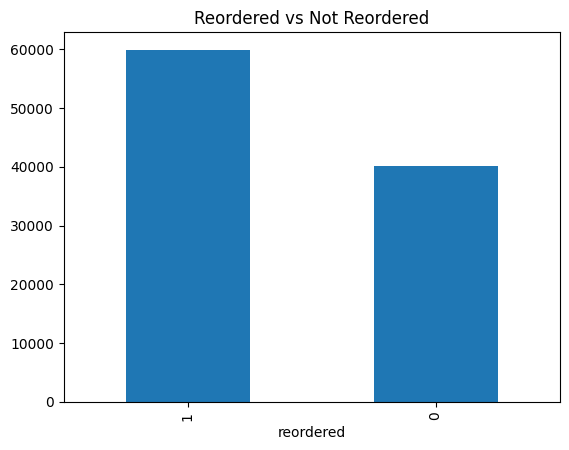

In [24]:
#target distribution
import matplotlib.pyplot as plt

y.value_counts().plot(kind='bar')
plt.title("Reordered vs Not Reordered")
plt.show()

Dataset is slightly imbalances, with about 60% reordered items

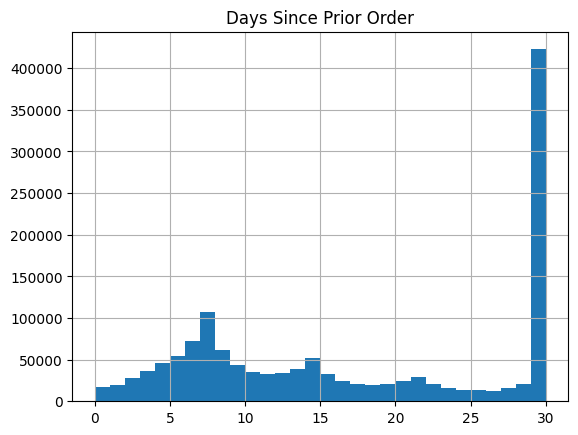

In [25]:
#days since prior order distribution
df["days_since_prior_order"].hist(bins=30)
plt.title("Days Since Prior Order")
plt.show()

Days since prior order
Bullets:

~60% of items are reordered (class imbalance)
Most purchases occur within short time intervals
High variation in product popularity
Moderate negative relationship between order frequency and user activity

Big spike at 30 days → monthly shoppers
Cluster around 5–10 days → weekly shoppers

In [26]:
#top product/popularity
product_counts.sort_values("product_popularity", ascending=False).head(10)

,product_id,product_name,product_popularity
19574,24852,Banana,18726
10367,13176,Bag of Organic Bananas,15480
16685,21137,Organic Strawberries,10894
17300,21903,Organic Baby Spinach,9784
37499,47626,Large Lemon,8135
37609,47766,Organic Avocado,7409
37164,47209,Organic Hass Avocado,7293
13228,16797,Strawberries,6494
20648,26209,Limes,6033
22024,27966,Organic Raspberries,5546


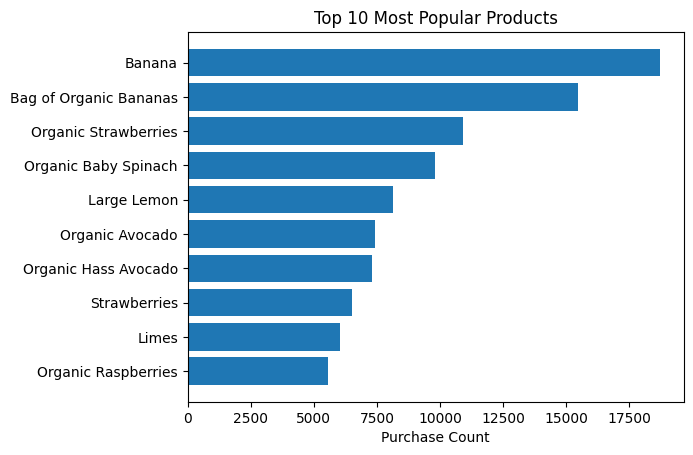

In [27]:
top_products = product_counts.sort_values("product_popularity", ascending=False).head(10)

plt.figure()
plt.barh(top_products["product_name"], top_products["product_popularity"])
plt.title("Top 10 Most Popular Products")
plt.xlabel("Purchase Count")
plt.gca().invert_yaxis()
plt.show()

In [28]:
#correlation/insight
df[["days_since_prior_order", "product_popularity", "user_total_orders"]].corr()

,days_since_prior_order,product_popularity,user_total_orders
days_since_prior_order,1.000000,-0.022039,-0.403861
product_popularity,-0.022039,1.000000,0.030843
user_total_orders,-0.403861,0.030843,1.000000


Exploratory Analysis

In [29]:
df.describe()

,order_id,product_id,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id,product_popularity,user_total_orders
count,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06
mean,1.706298e+06,2.555624e+04,5.985944e-01,1.031128e+05,1.709141e+01,2.701392e+00,1.357759e+01,1.706613e+01,7.130423e+01,9.839777e+00,1.434598e+03,1.709141e+01
std,9.897326e+05,1.412127e+04,4.901829e-01,5.948715e+04,1.661404e+01,2.167646e+00,4.238458e+00,1.042642e+01,3.810409e+01,6.292830e+00,3.148811e+03,1.661404e+01
min,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00
25%,8.433700e+05,1.338000e+04,0.000000e+00,5.173200e+04,6.000000e+00,1.000000e+00,1.000000e+01,7.000000e+00,3.100000e+01,4.000000e+00,6.600000e+01,6.000000e+00
50%,1.701880e+06,2.529800e+04,1.000000e+00,1.029330e+05,1.100000e+01,3.000000e+00,1.400000e+01,1.500000e+01,8.300000e+01,8.000000e+00,2.620000e+02,1.100000e+01
75%,2.568023e+06,3.794000e+04,1.000000e+00,1.549590e+05,2.100000e+01,5.000000e+00,1.700000e+01,3.000000e+01,1.070000e+02,1.600000e+01,1.149000e+03,2.100000e+01
max,3.421070e+06,4.968800e+04,1.000000e+00,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01,1.340000e+02,2.100000e+01,1.872600e+04,1.000000e+02


In [30]:
df['days_since_prior_order'].mean()

17.0661258672976

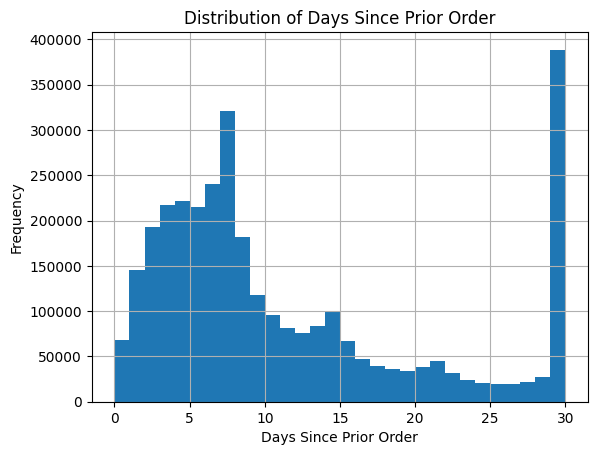

In [31]:
import matplotlib.pyplot as plt

orders['days_since_prior_order'].hist(bins=30)
plt.xlabel('Days Since Prior Order')
plt.ylabel('Frequency')
plt.title('Distribution of Days Since Prior Order')
plt.show()

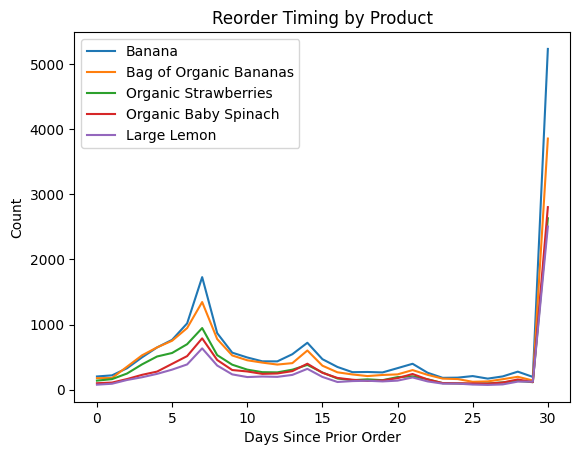

In [32]:
top_products = df['product_name_x'].value_counts().head(5).index
df_top = df[df['product_name_x'].isin(top_products)]

dist = (
    df_top.groupby(['days_since_prior_order', 'product_name_x'])
          .size()
          .reset_index(name='count')
)

for product in top_products:
    subset = dist[dist['product_name_x'] == product]
    plt.plot(subset['days_since_prior_order'], subset['count'], label=product)

plt.legend()
plt.xlabel('Days Since Prior Order')
plt.ylabel('Count')
plt.title('Reorder Timing by Product')
plt.show()

In [33]:
df.groupby('product_name_x')['reordered'].mean().sort_values(ascending=False)

product_name_x
+Energy Black Cherry Vegetable & Fruit Juice              1.0
0% Fat Greek Yogurt Black Cherry on the Bottom            1.0
eat your vegetables Vegetable Chips Sour Cream & Onion    1.0
Totally Ranch!                                            1.0
Tots Apple Whole Milk Greek Yogurt                        1.0
                                                         ... 
Local So Cal Raw & Unfiltered 100% Pure Honey             0.0
Lotzza Motzza 4-Meat Pizza                                0.0
Louis Jadot Chardonnay, Macon Villages                    0.0
Los Osos Merlot                                           0.0
Soothing Vapor Bath                                       0.0
Name: reordered, Length: 39123, dtype: float64

In [34]:
df.head(5)

,order_id,product_id,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name_x,aisle_id,department_id,aisle,department,product_name_y,product_popularity,user_total_orders
0,1,49302,1,112108,4,4,10,9.0,Bulgarian Yogurt,120,16,yogurt,dairy eggs,Bulgarian Yogurt,8,4
1,1,11109,1,112108,4,4,10,9.0,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs,Organic 4% Milk Fat Whole Milk Cottage Cheese,144,4
2,1,10246,0,112108,4,4,10,9.0,Organic Celery Hearts,83,4,fresh vegetables,produce,Organic Celery Hearts,1062,4
3,1,49683,0,112108,4,4,10,9.0,Cucumber Kirby,83,4,fresh vegetables,produce,Cucumber Kirby,2413,4
4,1,43633,1,112108,4,4,10,9.0,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods,Lightly Smoked Sardines in Olive Oil,24,4


In [35]:
df.head(10)

,order_id,product_id,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name_x,aisle_id,department_id,aisle,department,product_name_y,product_popularity,user_total_orders
0,1,49302,1,112108,4,4,10,9.0,Bulgarian Yogurt,120,16,yogurt,dairy eggs,Bulgarian Yogurt,8,4
1,1,11109,1,112108,4,4,10,9.0,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs,Organic 4% Milk Fat Whole Milk Cottage Cheese,144,4
2,1,10246,0,112108,4,4,10,9.0,Organic Celery Hearts,83,4,fresh vegetables,produce,Organic Celery Hearts,1062,4
3,1,49683,0,112108,4,4,10,9.0,Cucumber Kirby,83,4,fresh vegetables,produce,Cucumber Kirby,2413,4
4,1,43633,1,112108,4,4,10,9.0,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods,Lightly Smoked Sardines in Olive Oil,24,4
5,1,13176,0,112108,4,4,10,9.0,Bag of Organic Bananas,24,4,fresh fruits,produce,Bag of Organic Bananas,15480,4
6,1,47209,0,112108,4,4,10,9.0,Organic Hass Avocado,24,4,fresh fruits,produce,Organic Hass Avocado,7293,4
7,1,22035,1,112108,4,4,10,9.0,Organic Whole String Cheese,21,16,packaged cheese,dairy eggs,Organic Whole String Cheese,1993,4
8,36,39612,0,79431,23,6,18,30.0,Grated Pecorino Romano Cheese,2,16,specialty cheeses,dairy eggs,Grated Pecorino Romano Cheese,33,23
9,36,19660,1,79431,23,6,18,30.0,Spring Water,115,7,water seltzer sparkling water,beverages,Spring Water,2225,23


In [36]:
# Export the merged/cleaned dataframe
df.to_csv("instacart_cleaned.csv", index=False)
print("Saved!")

Saved!


In [37]:
# Generate reorder probabilities for all rows in X
all_reorder_prob = gb_model.predict_proba(X)[:, 1]

In [38]:
# Build export dataframe
reorder_predictions_df = df.loc[X.index, ["product_id", "product_name_x"]].copy()
reorder_predictions_df = reorder_predictions_df.rename(columns={"product_name_x": "product_name"})
reorder_predictions_df["reorder_probability"] = all_reorder_prob

In [39]:
# Aggregate to one row per product
reorder_product_df = (
    reorder_predictions_df
    .groupby(["product_id", "product_name"], as_index=False)["reorder_probability"]
    .mean()
)


In [40]:
# Optional: aggregate to product level so each product has one probability
reorder_product_df = (
    reorder_predictions_df
    .groupby(["product_id", "product_name"], as_index=False)["reorder_probability"]
    .mean()
)

In [41]:
reorder_product_df["reorder_probability"] = reorder_product_df["reorder_probability"].round(3)

In [42]:
print(reorder_product_df.shape)

(16760, 3)


In [43]:
# Save for AWS / Streamlit
reorder_product_df.to_csv("reorder_predictions.csv", index=False)

In [44]:
# Preview
print(reorder_product_df.head())

   product_id                                       product_name  \
0           1                         Chocolate Sandwich Cookies   
1           3               Robust Golden Unsweetened Oolong Tea   
2           4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
3          10     Sparkling Orange Juice & Prickly Pear Beverage   
4          12                         Chocolate Fudge Layer Cake   

   reorder_probability  
0                0.586  
1                0.331  
2                0.538  
3                0.631  
4                0.314  


In [45]:
# predictions uploaded to S3
import io

csv_buffer = io.StringIO()
reorder_product_df.to_csv(csv_buffer, index=False)

s3.put_object(
    Bucket=bucket,
    Key="predictions/reorder_predictions.csv",
    Body=csv_buffer.getvalue()
)

print("Reorder predictions uploaded to S3!")

Reorder predictions uploaded to S3!


In [46]:
# save model to S3
import joblib

joblib.dump(gb_model, "reorder_model.joblib")

s3.upload_file(
    "reorder_model.joblib",
    bucket,
    "model/reorder_model.joblib"
)

print("Reorder model saved to S3!")

Reorder model saved to S3!


The model learns patterns from past ordering behavior and outputs the probability that a product will be reordered based on features like how frequently it’s purchased, when it’s purchased, and user activity

In [ ]:
# Now upload predictions to RDS

In [50]:
import boto3

rds = boto3.client("rds", region_name="us-east-1")

response = rds.describe_db_instances(DBInstanceIdentifier="food-waste-db")
db = response["DBInstances"][0]

print("Engine:", db["Engine"])
print("Port:", db["Endpoint"]["Port"])
print("Endpoint:", db["Endpoint"]["Address"])
print("DB Name:", db.get("DBName", "not set"))

Engine: mysql
Port: 3306
Endpoint: food-waste-db.cxkacdkaxalv.us-east-1.rds.amazonaws.com
DB Name: not set


In [51]:
!pip install pymysql -q

import pymysql

conn = pymysql.connect(
    host="food-waste-db.cxkacdkaxalv.us-east-1.rds.amazonaws.com",
    user="admin",
    password="ChurnLab2026!",
    port=3306
)

cursor = conn.cursor()
print("Connected!")

Connected!


In [52]:
cursor.execute("CREATE DATABASE IF NOT EXISTS food_waste;")
cursor.execute("USE food_waste;")
conn.commit()
print("Database created!")

Database created!


In [53]:
cursor.execute("""
    CREATE TABLE IF NOT EXISTS waste_predictions (
        product_id INT,
        product_name TEXT,
        predicted_waste_category TEXT,
        prediction_confidence FLOAT,
        waste_risk TEXT
    );
""")

cursor.execute("""
    CREATE TABLE IF NOT EXISTS reorder_predictions (
        product_id INT,
        product_name TEXT,
        reorder_probability FLOAT
    );
""")

conn.commit()
print("Tables created!")

Tables created!


In [55]:
import boto3
import pandas as pd
from io import StringIO

s3 = boto3.client("s3", region_name="us-east-1")

obj = s3.get_object(Bucket="food-waste-project", Key="predictions/reorder_predictions.csv")
reorder_product_df = pd.read_csv(StringIO(obj["Body"].read().decode("utf-8")))

print("Shape:", reorder_product_df.shape)
print(reorder_product_df.head())

Shape: (16760, 3)
   product_id                                       product_name  \
0           1                         Chocolate Sandwich Cookies   
1           3               Robust Golden Unsweetened Oolong Tea   
2           4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
3          10     Sparkling Orange Juice & Prickly Pear Beverage   
4          12                         Chocolate Fudge Layer Cake   

   reorder_probability  
0                0.586  
1                0.331  
2                0.538  
3                0.631  
4                0.314  


In [56]:
for _, row in reorder_product_df.iterrows():
    cursor.execute("""
        INSERT INTO reorder_predictions
        (product_id, product_name, reorder_probability)
        VALUES (%s, %s, %s)
    """, (row["product_id"], row["product_name"], row["reorder_probability"]))

conn.commit()
cursor.close()
conn.close()
print("Reorder predictions uploaded to RDS!")

Reorder predictions uploaded to RDS!
